In [1]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
import numpy as np
import random

In [2]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


In [3]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

print("Seed:", seed)

Seed: 42


# 5.1 — Creating a DataLoader

In [4]:
batch_size = 32
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

# 5.2 — DataLoader Test

In [5]:
images , labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([6, 4, 4, 6, 5, 1, 3, 6, 6, 5, 3, 4, 2, 4, 6, 5, 2, 5, 3, 1, 4, 0, 6, 2,
        5, 1, 2, 3, 0, 6, 6, 4])


# 6.1 — Building the first block cnn

In [6]:
block1 = nn.Sequential(
    nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2)
)
print(block1)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


# 6.2 — Building the second block cnn

In [7]:
block2 = nn.Sequential(
    nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2)
)
print(block2)

Sequential(
  (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


# 6.3 — Building BaselineCNN

In [8]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Feature Extractor
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Classification Head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*56*56, num_classes)   # 200704 → 7
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x 
    

In [9]:
model = BaselineCNN(num_classes=7)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=7, bias=True)
  )
)


In [10]:
outputs = model(images)

print("Outputs shape:", outputs.shape)
print("Outputs:", outputs)

Outputs shape: torch.Size([32, 7])
Outputs: tensor([[ 1.7997e-01, -1.0588e-01,  1.8490e-01, -2.3693e-01, -1.2056e-01,
         -9.3115e-02,  3.9038e-02],
        [-8.9137e-02, -1.3233e-01,  2.2501e-01, -1.2180e-01, -1.9912e-01,
         -1.7300e-01, -2.0339e-02],
        [-5.0787e-02,  3.0065e-03, -5.3724e-02,  1.6279e-02, -1.5650e-01,
          4.6003e-02, -1.3287e-01],
        [ 8.4981e-02, -2.6255e-01,  1.2702e-01, -2.1438e-01, -3.4240e-01,
         -2.8791e-01, -9.7357e-02],
        [-3.2983e-04,  4.5125e-02,  3.0211e-01, -1.8845e-02, -1.9710e-01,
         -1.4654e-01,  2.4576e-02],
        [-7.1982e-02, -1.4648e-01,  2.0617e-01, -1.4950e-01, -3.6988e-01,
         -1.1113e-01, -9.4317e-02],
        [ 3.1288e-03, -3.6452e-01,  3.3471e-01, -2.6698e-01, -2.6987e-01,
         -2.5671e-01, -1.4288e-01],
        [ 9.4871e-02, -1.3422e-01,  1.1148e-01, -2.7420e-02, -6.7777e-02,
         -2.4173e-01, -8.8658e-02],
        [-5.5917e-02, -2.5040e-01,  2.5717e-01, -3.3717e-02, -1.4073e-01,
  

# 7.1 — Loss Function

In [11]:
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)
print("Loss:", loss.item())

Loss: 2.0099661350250244


# 7.2 — Optimizer

In [12]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# 7.3 — DEVICE

In [13]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print('Device:',device)

model = model.to(device)
print(next(model.parameters()).device)  #بررسی می‌کند که واقعاً پارامترهای مدل روی کجا قرار گرفته‌اند.

Device: cpu
cpu


# Training Phase

# 8.1 — Analysis of weight changes

In [14]:
# model.train()

# images , labels = next(iter(train_loader))
# images = images.to(device)

# labels = labels.to(device)
# optimizer.zero_grad()
# outputs = model(images)

# loss = criterion(outputs, labels)
# loss.backward()
# optimizer.step()

# print("Loss:", loss.item())

In [15]:
# print("First weight value:", model.features[0].weight[0, 0, 0, 0].item())

In [16]:
# model.train()
# images, labels = next(iter(train_loader))

# images = images.to(device)
# labels = labels.to(device)

# optimizer.zero_grad()
# outputs = model(images)

# loss = criterion(outputs, labels)
# loss.backward()
# optimizer.step()

# print("Loss:", loss.item())
# print("First weight value:", model.features[0].weight[0, 0, 0, 0].item())

# 8.2 — Training Loop for 1 epoch

In [17]:
model.train()
running_loss = 0.0  # برای جمع کردن Loss تمام Batchهاست.
for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

epoch_loss = running_loss / len(train_loader)  # میانگین Loss تمام Batchها را به دست می‌آوریم.
print("Train Loss:", epoch_loss)

Train Loss: 2.3301681587376546


# 8.3 — Validation Loop for 1 epoch

In [18]:
model.eval()
val_running_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

val_loss = val_running_loss / len(val_loader)
val_accuracy = correct / total
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

Validation Loss: 0.9064978671073913
Validation Accuracy: 0.6989664082687338


# 8.4 — Building a Complete Training Loop

In [19]:
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    
    # Training
    model.train()
    train_running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()
        train_running_loss += loss.item()

    train_loss = train_running_loss / len(train_loader)

    # Validation
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = correct / total


    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 0.6425 Val Loss: 0.6159 Val Accuracy: 0.7946
Epoch [2/10] Train Loss: 0.3971 Val Loss: 0.6594 Val Accuracy: 0.7674
Epoch [3/10] Train Loss: 0.2529 Val Loss: 0.5610 Val Accuracy: 0.7946
Epoch [4/10] Train Loss: 0.1431 Val Loss: 0.6912 Val Accuracy: 0.8010
Epoch [5/10] Train Loss: 0.0616 Val Loss: 0.7068 Val Accuracy: 0.8140
Epoch [6/10] Train Loss: 0.0275 Val Loss: 0.6845 Val Accuracy: 0.8243
Epoch [7/10] Train Loss: 0.0159 Val Loss: 0.8350 Val Accuracy: 0.8114
Epoch [8/10] Train Loss: 0.0045 Val Loss: 0.7646 Val Accuracy: 0.8307
Epoch [9/10] Train Loss: 0.0022 Val Loss: 0.7767 Val Accuracy: 0.8372
Epoch [10/10] Train Loss: 0.0015 Val Loss: 0.7918 Val Accuracy: 0.8346


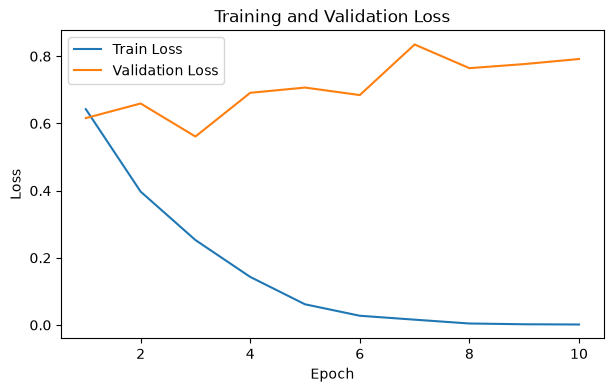

In [20]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

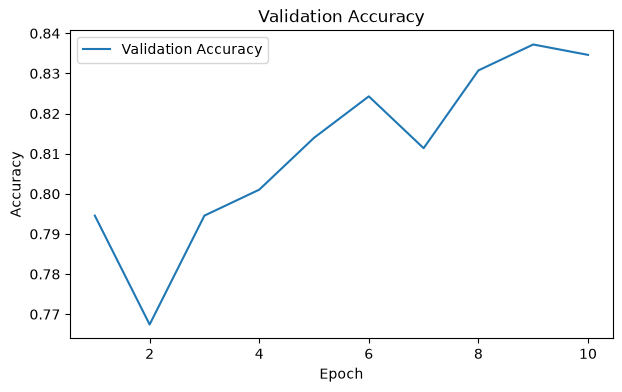

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 9.1 — Save the best model

In [22]:
model = BaselineCNN(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
# بهتر است هنگام آموزش، بهترین وضعیت مدل را ذخیره کنیم.
#چرا مدل جدید؟
# چون می‌خواهیم Baseline را از ابتدا دوباره آموزش بدهیم، اما این بار هر وقت 
# validation بهتر شد، مدل را ذخیره کنیم.

# 9.2 — Training Loop

In [23]:
num_epochs = 10
train_losses = []
val_losses = []
val_accuracies = []
best_val_accuracy = 0.0
best_epoch = 0

for epoch in range(num_epochs):

    # Training
    model.train()
    train_running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()

    train_loss = train_running_loss / len(train_loader)


    # Validation
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = correct / total

    # ذخیره نتایج
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save Best Model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../06_training/best_baseline_cnn.pth"
        )
        print("  --> Best model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

  --> Best model saved!
Epoch [1/10] Train Loss: 2.2535 Val Loss: 1.1007 Val Accuracy: 0.6072
  --> Best model saved!
Epoch [2/10] Train Loss: 0.7270 Val Loss: 0.8107 Val Accuracy: 0.7274
Epoch [3/10] Train Loss: 0.4076 Val Loss: 0.7757 Val Accuracy: 0.7261
  --> Best model saved!
Epoch [4/10] Train Loss: 0.2766 Val Loss: 0.8288 Val Accuracy: 0.7506
  --> Best model saved!
Epoch [5/10] Train Loss: 0.1453 Val Loss: 0.8697 Val Accuracy: 0.7791
Epoch [6/10] Train Loss: 0.0646 Val Loss: 0.9167 Val Accuracy: 0.7674
Epoch [7/10] Train Loss: 0.0325 Val Loss: 0.9929 Val Accuracy: 0.7700
  --> Best model saved!
Epoch [8/10] Train Loss: 0.0151 Val Loss: 0.9855 Val Accuracy: 0.7997
Epoch [9/10] Train Loss: 0.0061 Val Loss: 1.0364 Val Accuracy: 0.7829
Epoch [10/10] Train Loss: 0.0038 Val Loss: 1.0540 Val Accuracy: 0.7881

Best Epoch: 8
Best Validation Accuracy: 0.7997416020671835


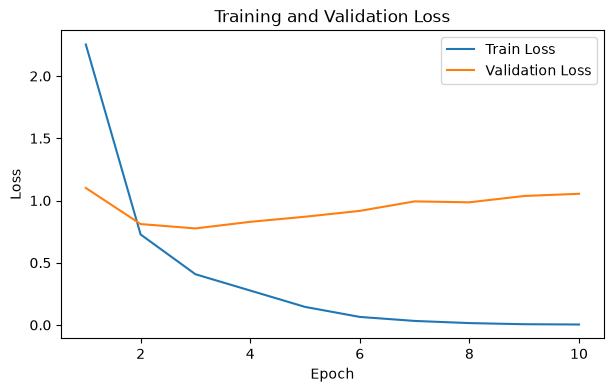

In [24]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(7, 4))

plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

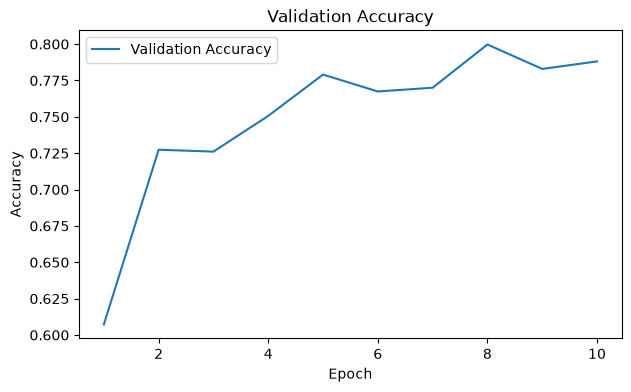

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.legend()
plt.show()

# 9.3 — Baseline evaluation on the validation set

In [ ]:
# load model
model.load_state_dict(
    torch.load(
        "../06_training/best_baseline_cnn.pth",
        map_location=device
    )
)
model = model.to(device)
model.eval()
print("Best Baseline Model Loaded")

Best Baseline Model Loaded


In [27]:
all_predictions = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 9.4 — Precision , Recall , F1 , confusion_matrix

In [28]:
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average="macro")
recall = recall_score(all_labels, all_predictions, average="macro")
f1 = f1_score(all_labels, all_predictions, average="macro")
cm = confusion_matrix(all_labels, all_predictions)

print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Validation Accuracy : 0.7997416020671835
Validation Precision: 0.8163834679804909
Validation Recall   : 0.7953996190844611
Validation F1 Score : 0.8023957221019107
confusion_matrix    :
 [[ 49   1  12   1   6   0   3]
 [  1  67  17   3   2   2   1]
 [  8   9 151  12   1   4   4]
 [  1   0  19  58   0   0   0]
 [  1   0   2   0  90   1   6]
 [  1   0   2   0   1  93   0]
 [  1   0  16   1  15   1 111]]


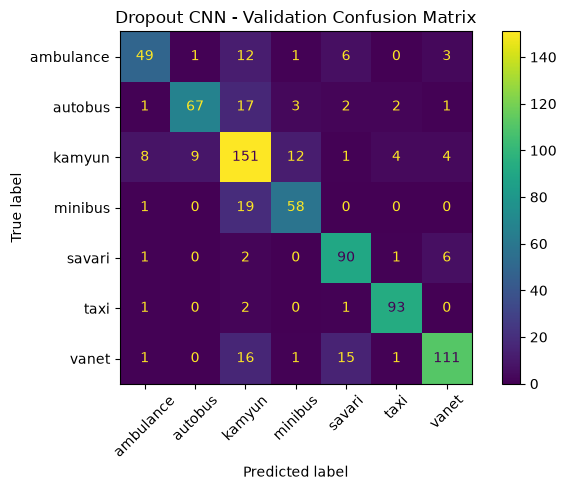

In [29]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title("Dropout CNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

# classification_report

In [30]:
report = classification_report(all_labels, all_predictions, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.79      0.68      0.73        72
     autobus       0.87      0.72      0.79        93
      kamyun       0.69      0.80      0.74       189
     minibus       0.77      0.74      0.76        78
      savari       0.78      0.90      0.84       100
        taxi       0.92      0.96      0.94        97
       vanet       0.89      0.77      0.82       145

    accuracy                           0.80       774
   macro avg       0.82      0.80      0.80       774
weighted avg       0.81      0.80      0.80       774

